Analise Venda

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

Leitura de Dados

In [20]:
df = pd.read_excel("dados_vendas_brutos_corrigidos.xlsx", engine="openpyxl")

Visualização dos Dados

In [ ]:
display(df.sample(10))
display(df.info())
display(df.dtypes)
display(df.isnull().sum())

Limpeza e Análise das Datas

In [22]:
df["data"] = pd.to_datetime(df["data"], errors="coerce")

df["nome_mes"] = df["data"].dt.month_name(locale="pt_BR")
df["nome_dia"] = df["data"].dt.day_name(locale="pt_BR")
df["mes_ano"] = df["data"].dt.to_period("M")

Enriquecimento da Coluna Valor Venda

In [23]:
df["valor_venda"] = df["quantidade"] * df["preco_unitario"]

Gráfico Produto Venda

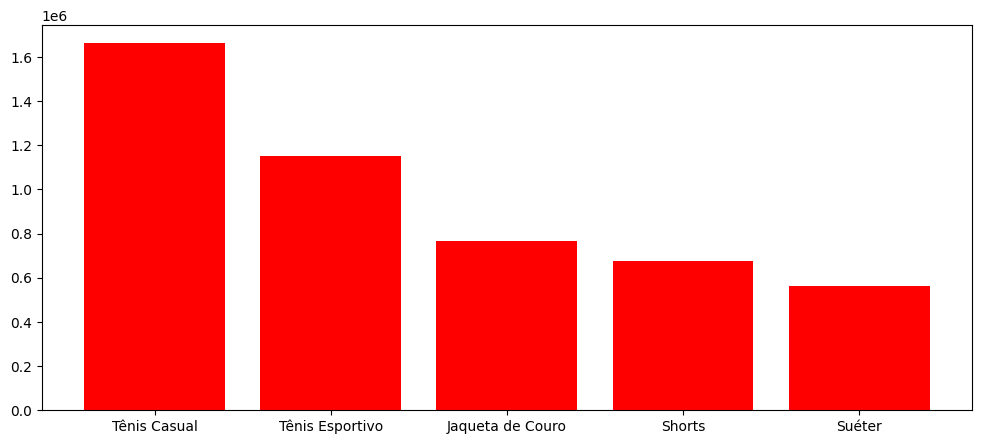

In [ ]:
produto_venda = df.groupby("produto").agg(
    total_venda=("valor_venda", "sum")
).reset_index().sort_values("total_venda", ascending=False)

plt.figure(figsize=(12,5))

plt.bar(produto_venda["produto"], produto_venda["total_venda"], color="red")
plt.show()

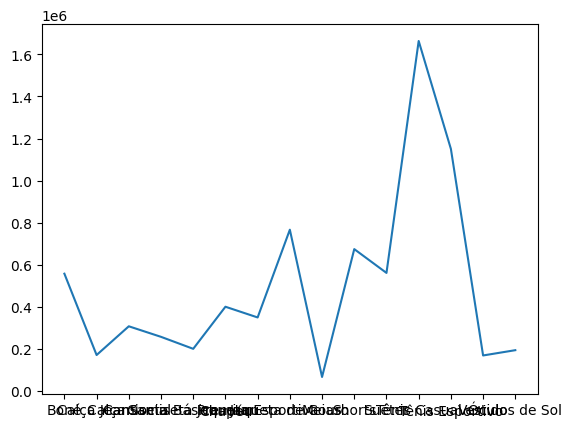

In [38]:
produto_venda = df.groupby("produto").agg(
    total_venda=("valor_venda", "sum")
).reset_index()

plt.plot(produto_venda["produto"], produto_venda["total_venda"])
plt.show()